In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [82]:
df = pd.read_csv("../data/Telco_Customer_Churn.csv")
df.shape

(7043, 21)

# Predict churn to retain customers
**Each row is a customer**
### Main columns:
- Services used by the customer
- Churn: customers who left last month
- Customer account preferences: payment menthod, contract, etc...
- Demogaraphic about the customer: age, gender, family infos

In [83]:
df.head()
pd.set_option('display.max_columns', None) # show all columns
pd.set_option('display.max_rows', None) # show all rows

In [84]:
df.describe(include='all')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Convert binary variables to 0/1
## Convert 2+ categories variables with One Hot Encoding

In [85]:
binary_cols = ["gender","Partner","Dependents","PhoneService","PaperlessBilling","Churn"]
df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0, 'Male':1,'Female':0})

multicat_cols = ["MultipleLines","InternetService","OnlineSecurity","OnlineBackup","DeviceProtection",
                 "TechSupport","StreamingTV","StreamingMovies","Contract","PaymentMethod"]
df = pd.get_dummies(df, columns=multicat_cols, drop_first=True)


/var/folders/yb/vbtzq9693hq7ytp6nmv278d00000gn/T/ipykernel_76724/4201567921.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0, 'Male':1,'Female':0})


In [86]:
# Convert TotalCharges to numeric and make sure empty values are treated as NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
# Drop Customer ID, not relevant for modeling
df = df.drop('customerID', axis=1)

# Turn booleans to integers
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   int64  
 11  Mult

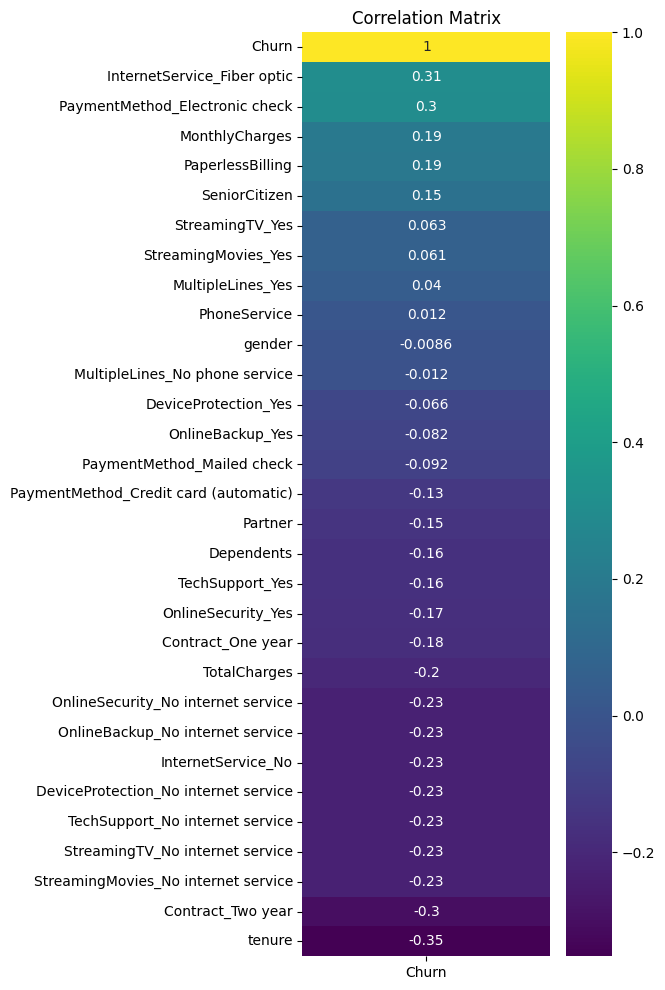

In [87]:
corr_matrix = df.corr(numeric_only=True)
churn_corr = corr_matrix["Churn"].sort_values(ascending=False)
churn_corr_df = pd.DataFrame(churn_corr)
plt.figure(figsize=(4,12))
sns.heatmap(churn_corr_df, annot=True, cmap='viridis')
plt.title("Correlation Matrix")
plt.show()

# We can see the columns that highly correlate with churn

In [88]:
# After seeing the correlation matrix, we want to know if there
# are multicollinearity issues for the columns that correlate with churn

# Redundant columns that indicate no internet service
internet_service_cols = [col for col in df.columns if 'No internet service' in col or 'InternetService_No' in col]
df['No_internet_service'] = df[internet_service_cols].any(axis=1).astype(int)
df = df.drop(columns=internet_service_cols)

if 'MultipleLines_No phone service' in df.columns:
    df['No_phone_service'] = df['MultipleLines_No phone service'].astype(int)
    df = df.drop(columns=['MultipleLines_No phone service'])
if 'No_phone_service' in df.columns:
    df = df.drop(columns=['No_phone_service'])


In [89]:
X = df.drop(columns=['Churn'])
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

X = X.replace([np.inf, -np.inf], np.nan).dropna()

vif_data_df = pd.DataFrame()
vif_data_df["feature"] = X.columns
vif_data_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data_df = vif_data_df.sort_values(by="VIF", ascending=False)
print(vif_data_df)

                                  feature         VIF
7                          MonthlyCharges  212.353073
5                            PhoneService   47.244378
8                            TotalCharges   21.374002
4                                  tenure   20.482153
10            InternetService_Fiber optic   17.695260
22                    No_internet_service    8.234451
16                    StreamingMovies_Yes    5.090603
15                        StreamingTV_Yes    4.928957
18                      Contract_Two year    3.487502
13                   DeviceProtection_Yes    2.992570
6                        PaperlessBilling    2.956951
20         PaymentMethod_Electronic check    2.955994
12                       OnlineBackup_Yes    2.909898
9                       MultipleLines_Yes    2.861614
2                                 Partner    2.824725
14                        TechSupport_Yes    2.758343
11                     OnlineSecurity_Yes    2.682712
21             PaymentMethod

In [ ]:
# We want to see the balance of the dataset
df["Churn"].value_counts()[1] / (df["Churn"].value_counts()[0]+df["Churn"].value_counts()[1])
# We have a class imbalance problem (27% churners vs 73% non-churners)

np.float64(0.2653698707936959)